In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.metrics import log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from matplotlib import pyplot as plt
%config InlineBackend.figure_format = 'retina'
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

SGDRegressor taken from the course: linear regression trained with stochastic gradient descent, tracking MSE and weights at each update

In [5]:
class SGDRegressor(BaseEstimator):
    def __init__(self, eta=1e-3, n_epochs=3):
        self.eta = eta
        self.n_epochs = n_epochs
        self.mse_ = []
        self.weights_ = []

    def fit(self, X, y):
        X = np.hstack([np.ones([X.shape[0], 1]), X])

        w = np.zeros(X.shape[1])

        for it in tqdm(range(self.n_epochs)):
            for i in range(X.shape[0]):
                new_w = w.copy()
                err = y[i] - w.dot(X[i, :])
                new_w[0] += self.eta * err
                for j in range(1, X.shape[1]):
                    new_w[j] += self.eta * err * X[i, j]
                w = new_w.copy()

                self.weights_.append(w)
                self.mse_.append(mean_squared_error(y, X.dot(w)))

        self.w_ = self.weights_[np.argmin(self.mse_)]

        return self

    def predict(self, X):
        X = np.hstack([np.ones([X.shape[0], 1]), X])
        return X.dot(self.w_)


In [ ]:
file_path = r"M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week2/data/day.csv"
df = pd.read_csv(file_path)

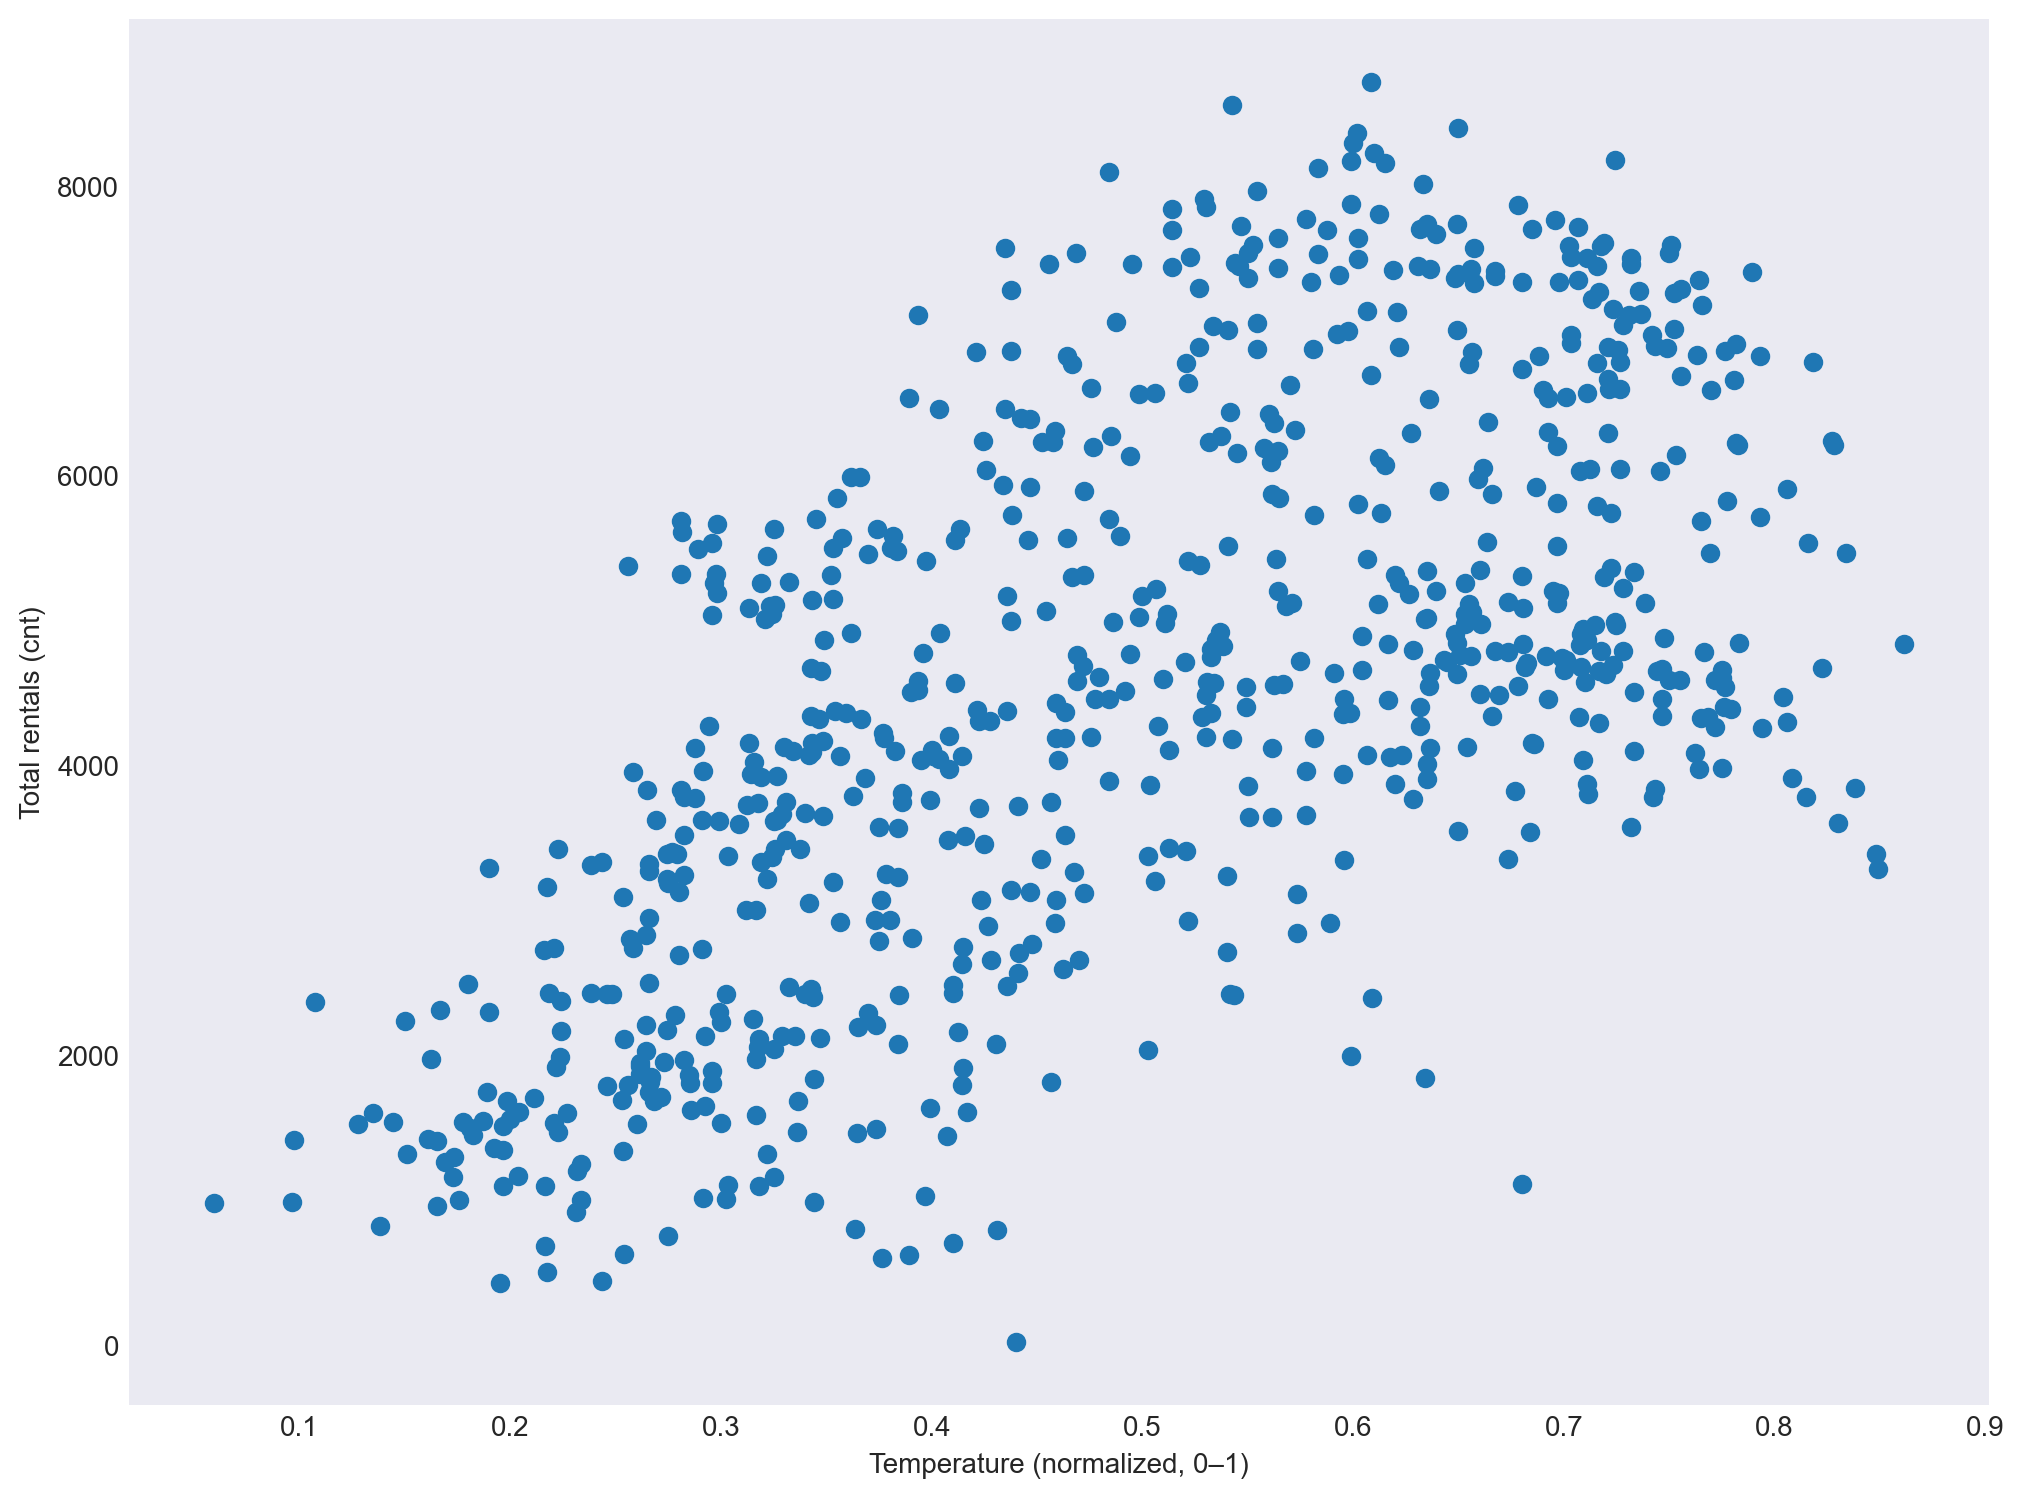

In [9]:
plt.scatter(df["temp"], df["cnt"])
plt.xlabel("Temperature (normalized, 0–1)")
plt.ylabel("Total rentals (cnt)")
plt.grid()

let's define 

X = temperature

y = total bike rentals

In [10]:
X = df["temp"].values
y = df["cnt"].values

split into train and hold-out (validation) sets and scale X (1D) with StandardScaler

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=17
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape([-1, 1]))
X_valid_scaled = scaler.transform(X_valid.reshape([-1, 1]))

training with default parameteres

In [12]:
sgd_reg = SGDRegressor()
sgd_reg.fit(X_train_scaled, y_train)

100%|██████████| 3/3 [00:00<00:00,  7.40it/s]


,eta,0.001
,n_epochs,3


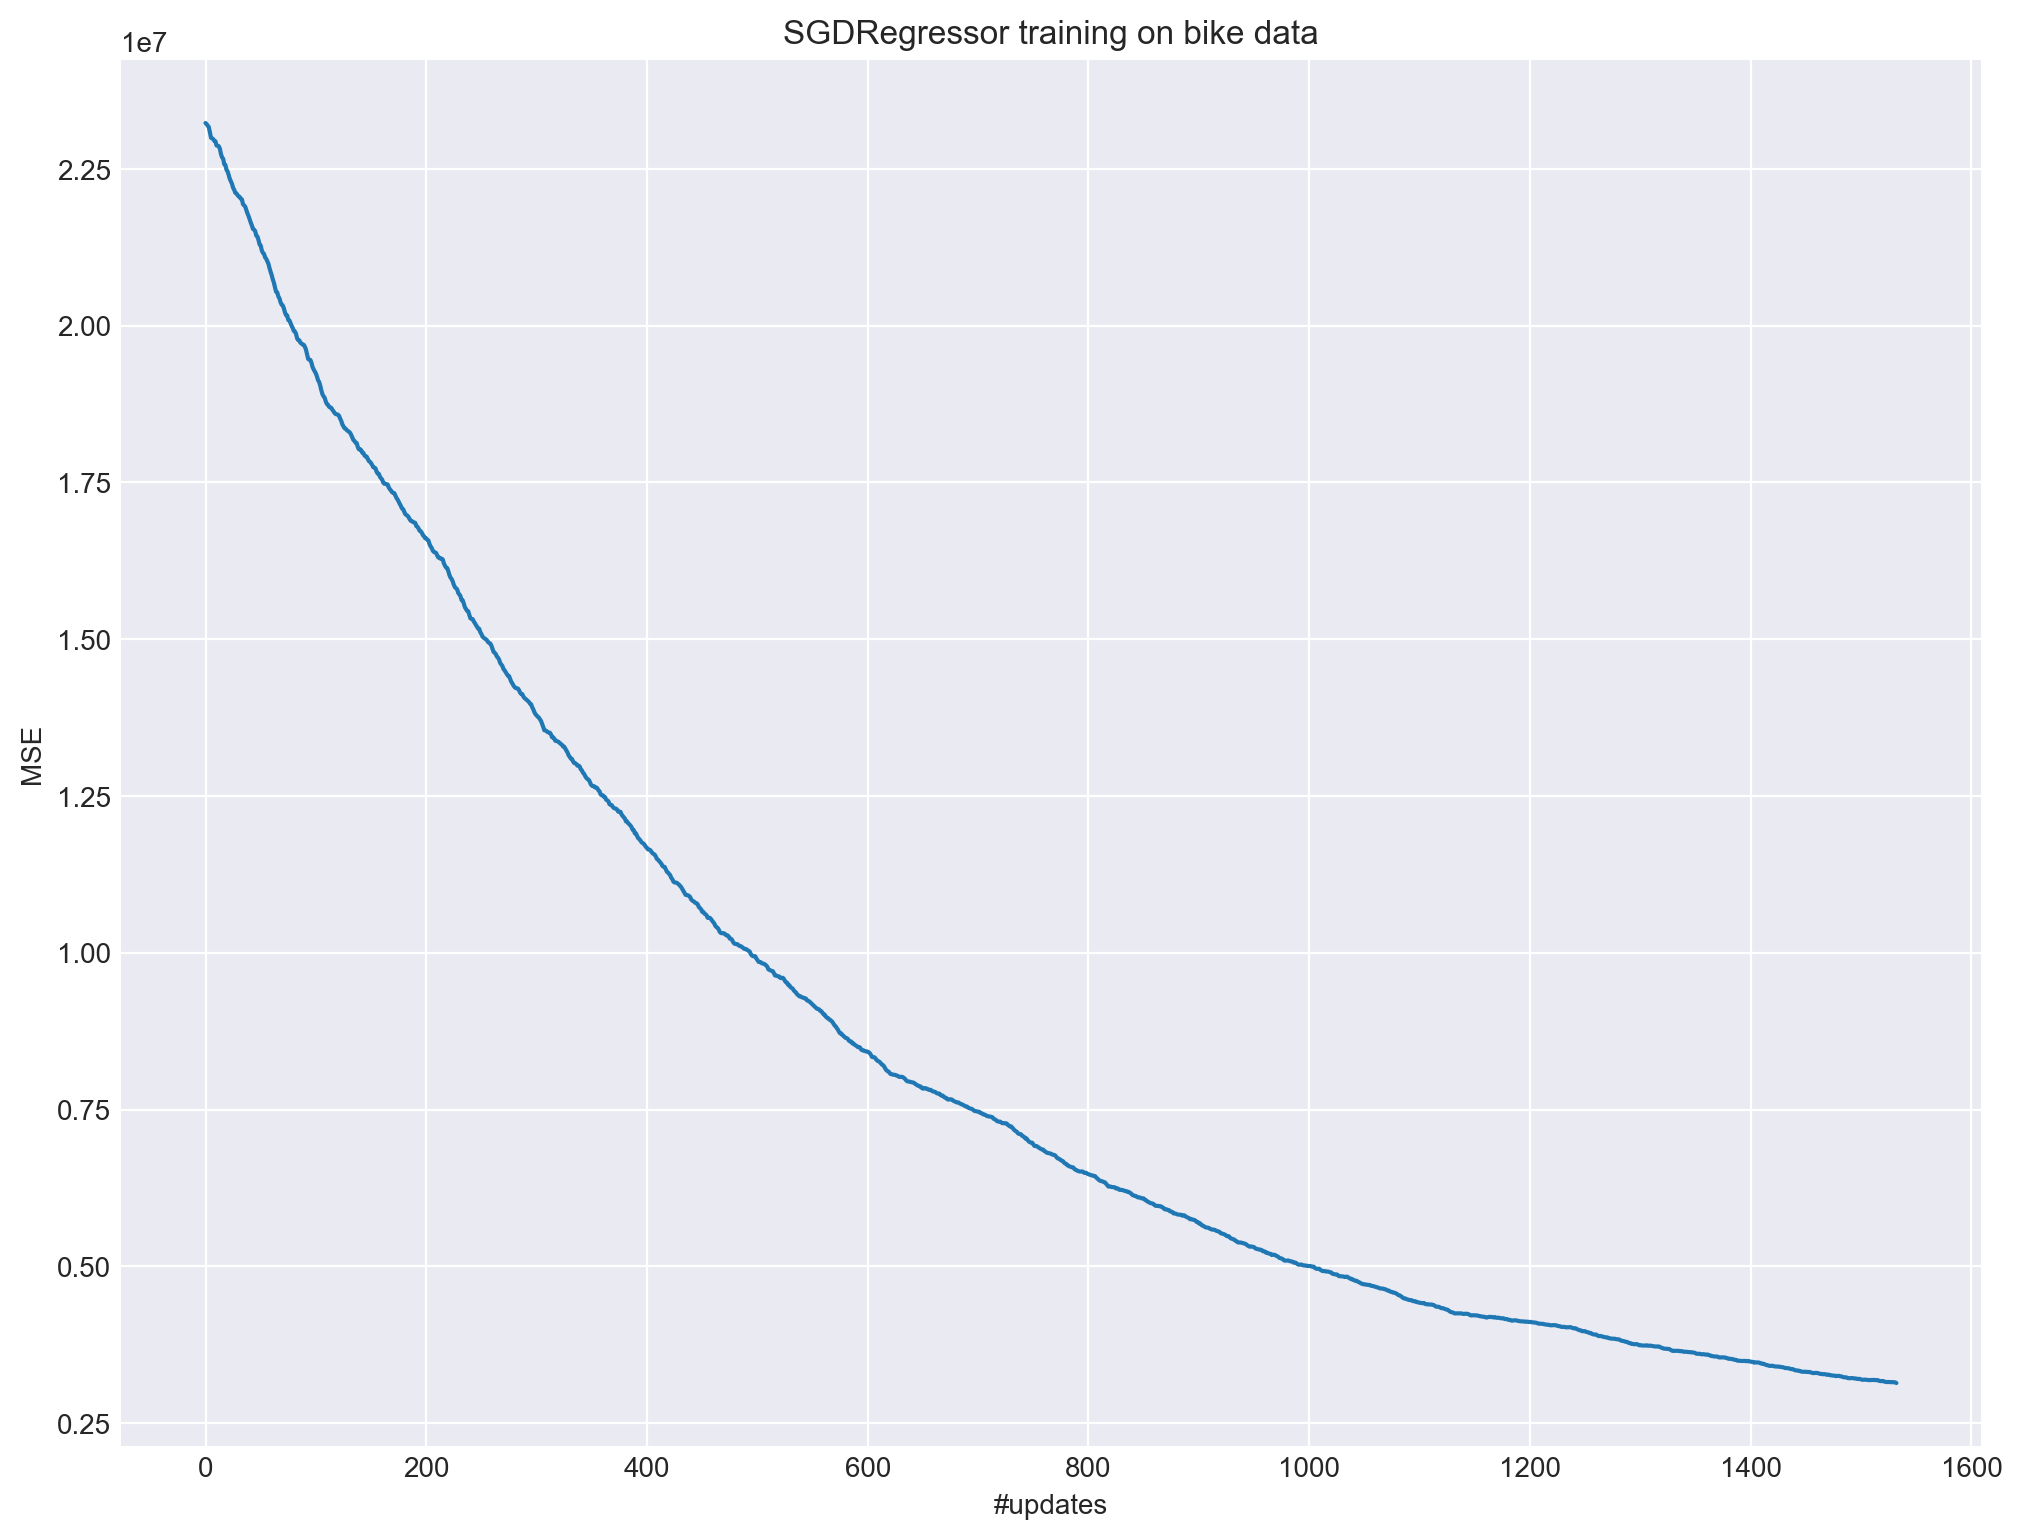

In [13]:
plt.plot(range(len(sgd_reg.mse_)), sgd_reg.mse_)
plt.xlabel("#updates")
plt.ylabel("MSE")
plt.title("SGDRegressor training on bike data");

In [14]:
np.min(sgd_reg.mse_), sgd_reg.w_

(np.float64(3138523.847882212), array([3470.22160321,  981.75158412]))

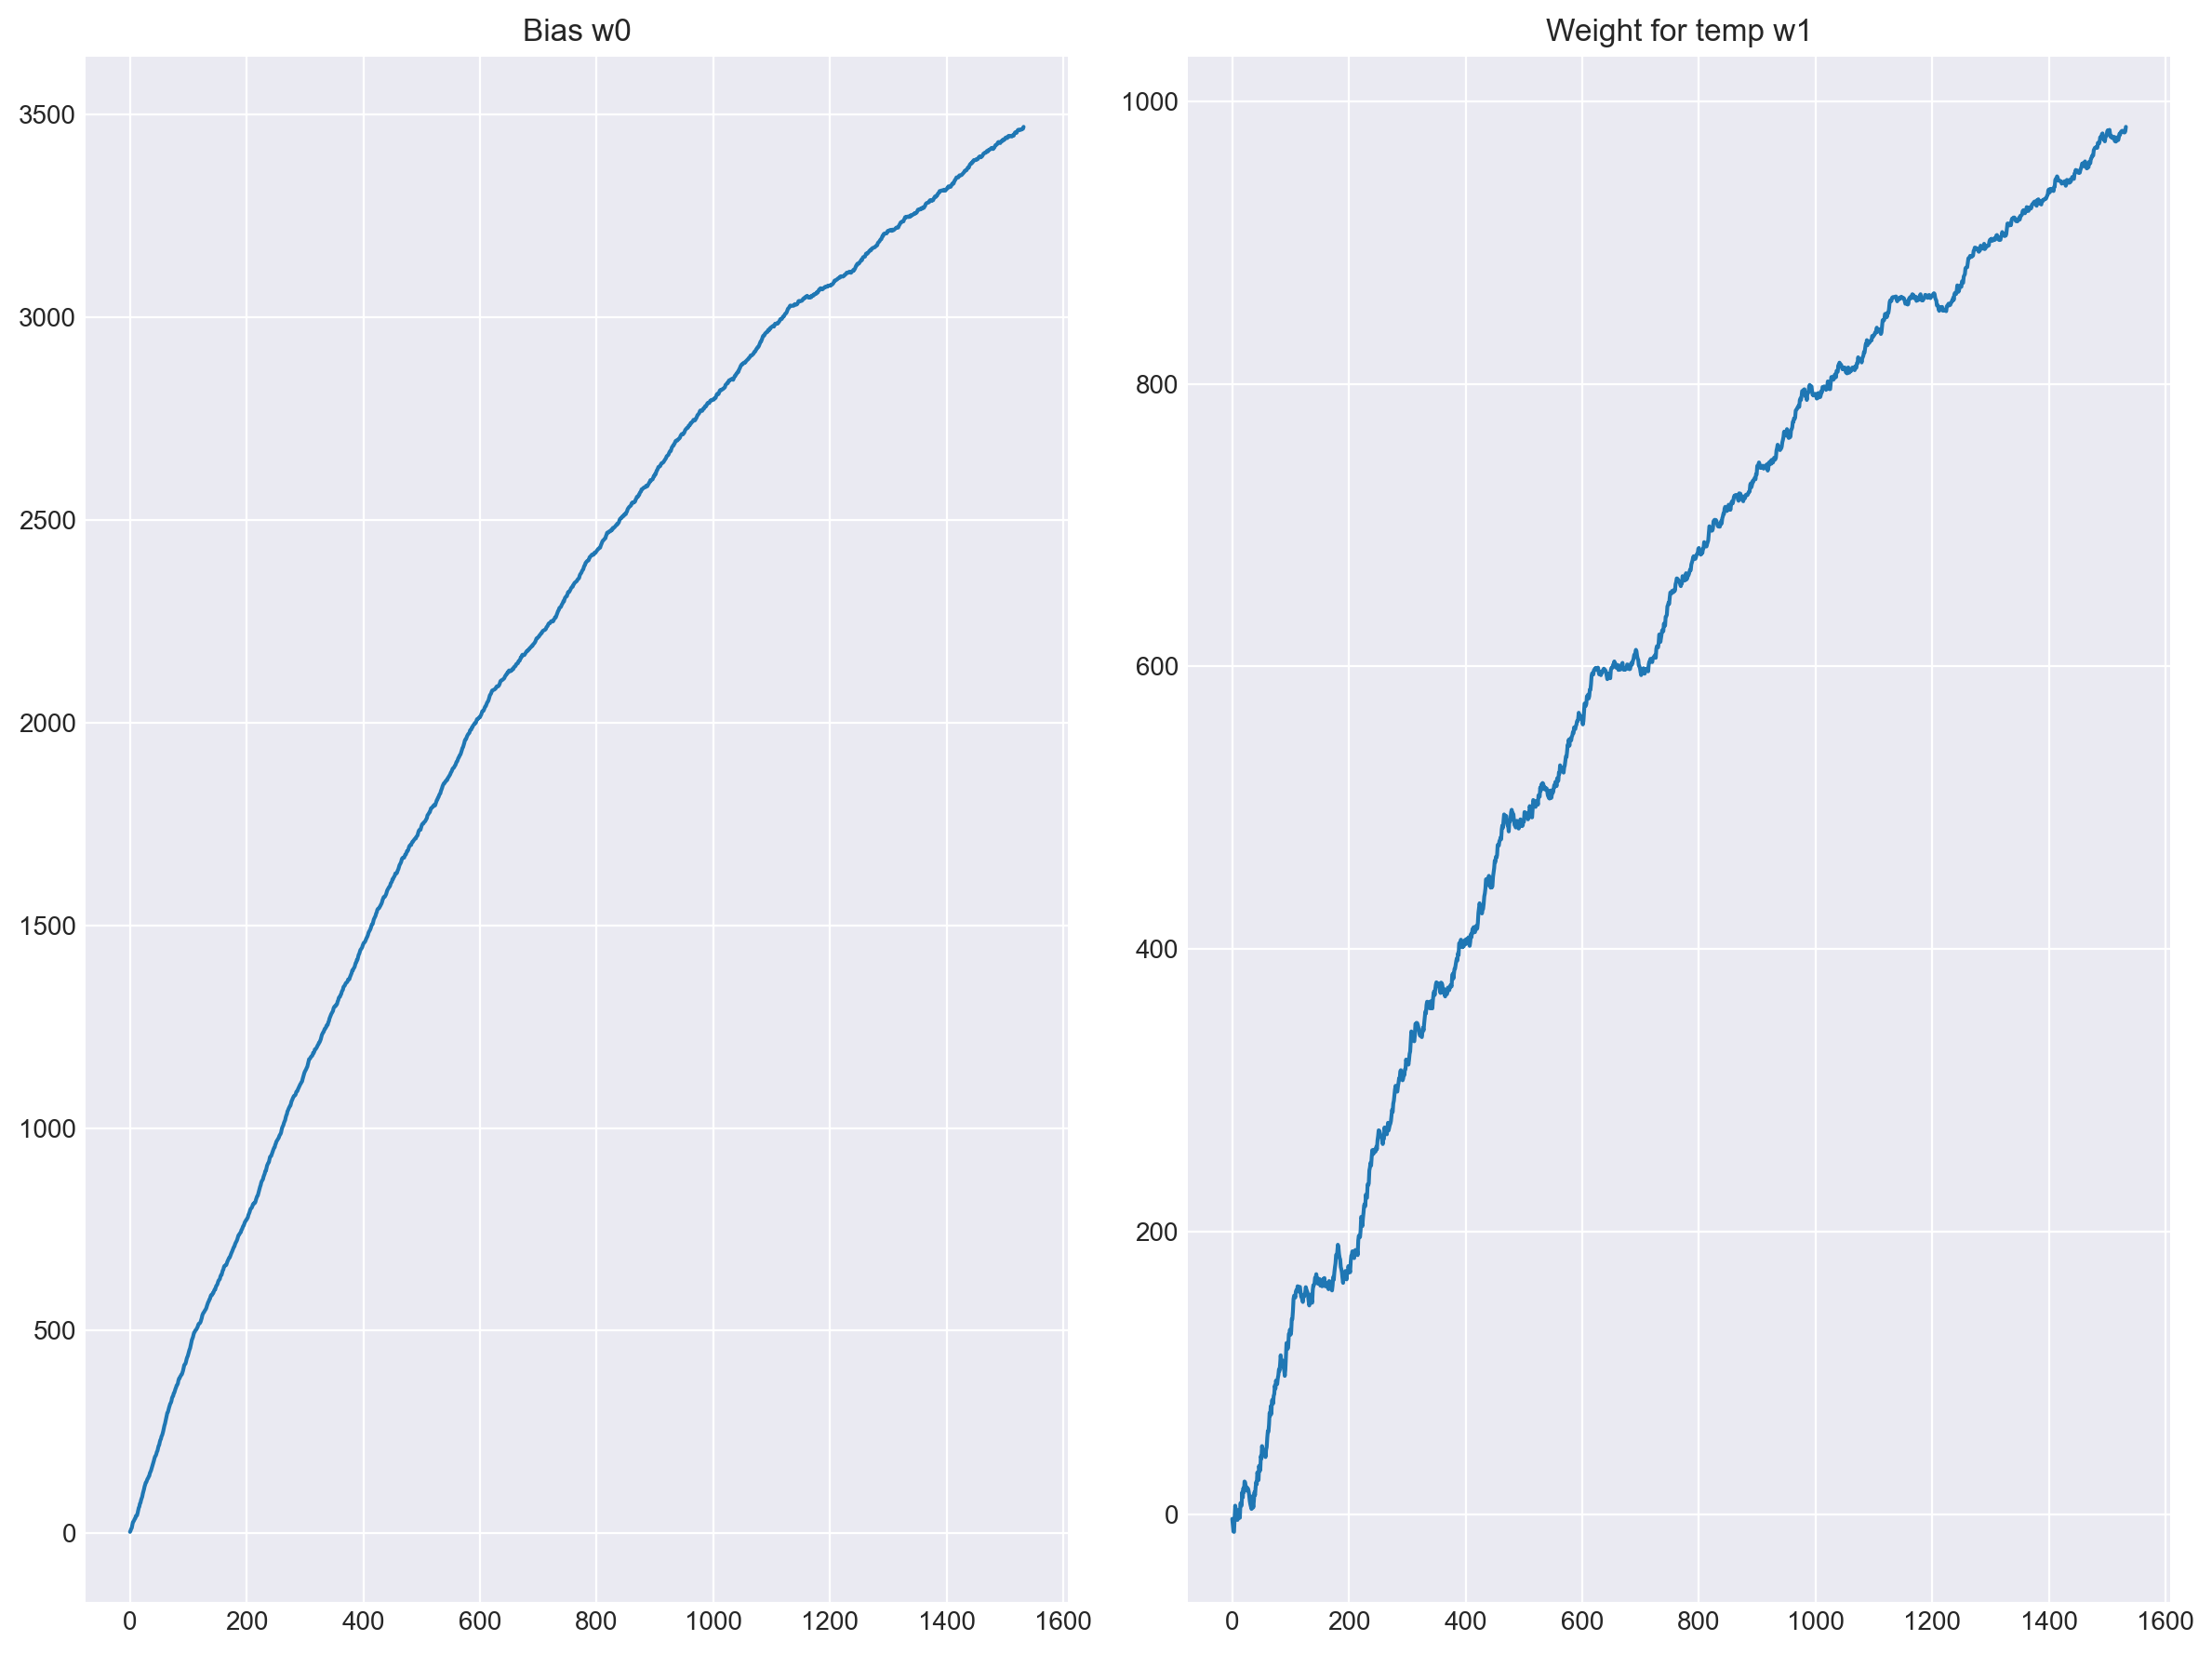

In [ ]:
plt.subplot(121)
plt.plot(range(len(sgd_reg.weights_)), [w[0] for w in sgd_reg.weights_])
plt.title("Bias w0")

plt.subplot(122)
plt.plot(range(len(sgd_reg.weights_)), [w[1] for w in sgd_reg.weights_])
plt.title("Weight for temp w1")
plt.tight_layout()

In [16]:
sgd_holdout_mse = mean_squared_error(y_valid, sgd_reg.predict(X_valid_scaled))
sgd_holdout_mse

3515690.0723672304

In [19]:

lm = LinearRegression().fit(X_train_scaled, y_train)
print("LinearRegression coef and intercept:", lm.coef_, lm.intercept_)
linreg_holdout_mse = mean_squared_error(y_valid, lm.predict(X_valid_scaled))
linreg_holdout_mse


LinearRegression coef and intercept: [1244.5388617] 4419.8043052837575


2518067.915722989

In [21]:
print("Linreg's holdout MSE:", linreg_holdout_mse)
print("SGD's holdout MSE:", sgd_holdout_mse)
print("Difference:", sgd_holdout_mse - linreg_holdout_mse)

Linreg's holdout MSE: 2518067.915722989
SGD's holdout MSE: 3515690.0723672304
Difference: 997622.1566442414
